In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [3]:
df = pd.json_normalize(df.to_dict(orient="records"))

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
df = df.rename(columns={
    'customer.gender':'gender',
    'customer.SeniorCitizen':'SeniorCitizen',
    'customer.Partner':'Partner',
    'customer.Dependents':'Dependents',
    'customer.tenure':'tenure',
    'phone.PhoneService':'PhoneService',
    'phone.MultipleLines':'MultipleLines',
    'internet.InternetService':'InternetService',
    'internet.OnlineSecurity':'OnlineSecurity',
    'internet.OnlineBackup':'OnlineBackup',
    'internet.DeviceProtection':'DeviceProtection',
    'internet.TechSupport':'TechSupport',
    'internet.StreamingTV':'StreamingTV',
    'internet.StreamingMovies':'StreamingMovies',
    'account.Contract':'Contract',
    'account.PaperlessBilling':'PaperlessBilling',
    'account.PaymentMethod':'PaymentMethod',
    'account.Charges.Monthly':'MonthlyCharges',
    'account.Charges.Total':'TotalCharges'
})

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMovies   7256 non-null   object 
 16  Contract          7256 non-null   object 
 17  

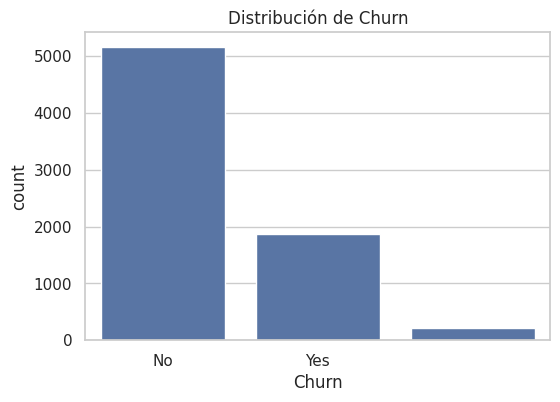

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Distribución de Churn")

plt.savefig("churn_general.png")

plt.show()

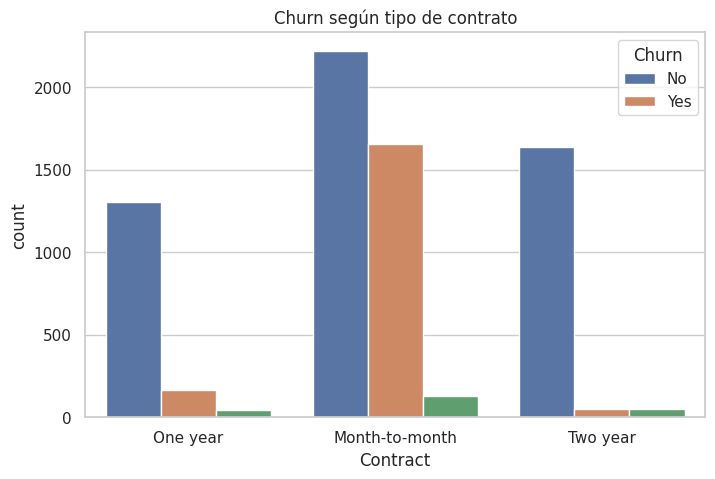

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn según tipo de contrato")

plt.savefig("churn_contrato.png")

plt.show()

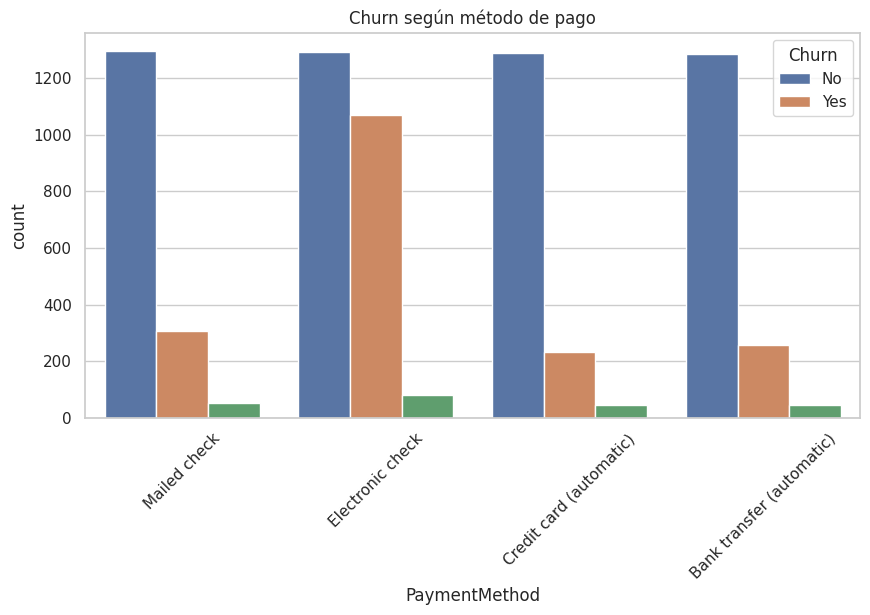

In [8]:
plt.figure(figsize=(10,5))

sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=45)

plt.title("Churn según método de pago")

plt.savefig("churn_pago.png")

plt.show()

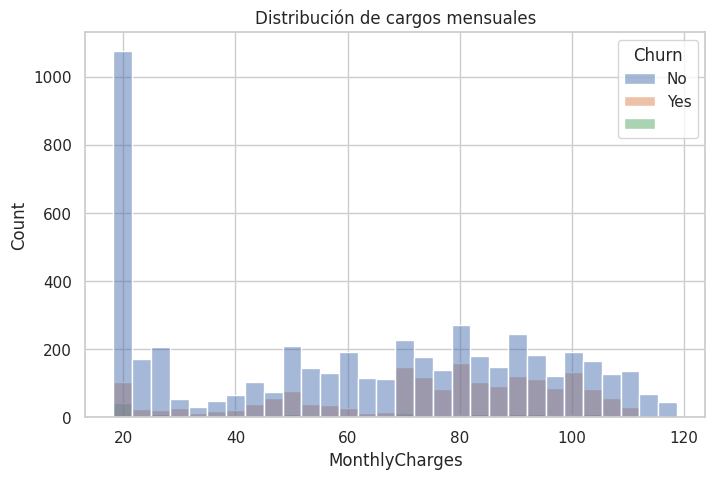

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df, x="MonthlyCharges", hue="Churn", bins=30)

plt.title("Distribución de cargos mensuales")

plt.savefig("churn_cargos.png")

plt.show()

In [10]:
print("Conclusiones del análisis:")

print("- Los contratos mensuales presentan mayor tasa de cancelación.")
print("- Los clientes con menor tiempo en la empresa tienen mayor churn.")
print("- Algunos métodos de pago presentan mayor riesgo de abandono.")

Conclusiones del análisis:
- Los contratos mensuales presentan mayor tasa de cancelación.
- Los clientes con menor tiempo en la empresa tienen mayor churn.
- Algunos métodos de pago presentan mayor riesgo de abandono.
